# AgroLab AI — Análise Exploratória de Dados (EDA)
## Alface Crespa · Hidroponia NFT × Solo Convencional

**Projeto:** Iniciação Científica — AgroLab AI
**Cultura:** *Lactuca sativa* var. *crispa* (alface crespa)
**Datasets:** `nft/dataset_nft.csv` (200.900 × 30) e `solo/dataset_solo.csv` (200.900 × 23)
**Documentação de método:** `info.md`

---

### Objetivo desta EDA

1. **Caracterizar** os datasets gerados (distribuições, correlações, balanceamento).
2. **Validar** que o gerador produziu o que a literatura prevê (*sanity checks* físicos e agronômicos).
3. **Avaliar se o problema é aprendível** — se um modelo consegue recuperar as regras de decisão.
4. **Fundamentar o argumento do NFT** para o artigo, com o enquadramento metodologicamente correto (ver aviso abaixo).

---

## ⚠️ Aviso metodológico — leia antes de interpretar qualquer gráfico

Este ponto é **decisivo para o artigo** e evita uma crítica fatal em banca.

Os dois datasets são **sintéticos**: as variáveis ambientais vêm de clima real (NASA POWER corrigido), mas as variáveis de manejo foram **geradas por regras que nós mesmos definimos** a partir da literatura (`info.md` §6, §7).

**Consequência lógica:** comparar solo × NFT *nestes dados* e concluir "o NFT é melhor" seria **circular** — as diferenças que aparecerem são consequência das nossas premissas de geração, não evidência empírica sobre o mundo real.

| A EDA **PODE** afirmar | A EDA **NÃO PODE** afirmar |
|---|---|
| Como os dados estão distribuídos e balanceados | Que o NFT produz mais que o solo |
| Que o gerador respeita as faixas da literatura | Que o NFT usa menos água |
| Que as relações físicas programadas se sustentam | Qualquer conclusão agronômica **nova** |
| Que o problema é aprendível por um modelo | Que a IA "descobriu" algo sobre a alface |

**Então como justificar o NFT no artigo?** Por duas vias legítimas:

1. **Evidência da literatura** (levantada na fase de pesquisa): rendimento por área muito superior, uso de água drasticamente menor, ciclo mais curto — com as devidas contrapartidas (custo energético e de capital mais altos, menor tamponamento).
2. **Argumento de controlabilidade** — e *este* a EDA sustenta com dados: o NFT possui **mais variáveis mensuráveis e acionáveis** que o solo. É justamente isso que torna a decisão automatizada por IA mais viável e mais valiosa no NFT. Vamos quantificar isso na Parte 12.

---

## Parte 1 — Configuração e carga dos dados

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# --- estilo dos gráficos ---
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'figure.autolayout': True,
})

# cores fixas por classe de ação (mesma legenda em todo o notebook)
CORES_CLASSE = {0: '#2e7d32', 1: '#c62828', 2: '#1565c0', 3: '#ef6c00'}
NOMES_CLASSE = {0: '0 · Não fazer nada', 1: '1 · Travar/corrigir excesso',
                2: '2 · Repor/corrigir falta', 3: '3 · Proteger (extremos)'}

BASE = Path('.')
nft  = pd.read_csv(BASE/'nft'/'dataset_nft.csv', parse_dates=['timestamp'])
solo = pd.read_csv(BASE/'solo'/'dataset_solo.csv', parse_dates=['timestamp'])

print(f'NFT  : {nft.shape[0]:,} linhas x {nft.shape[1]} colunas')
print(f'SOLO : {solo.shape[0]:,} linhas x {solo.shape[1]} colunas')
print(f'Período: {nft.timestamp.min():%d/%m/%Y} a {nft.timestamp.max():%d/%m/%Y}')

NFT  : 200,900 linhas x 30 colunas
SOLO : 200,900 linhas x 23 colunas
Período: 01/01/2015 a 31/12/2025


### 1.1 As variáveis do dataset NFT

Cada linha é **um estado do cultivo num dia** + **a ação correta** para aquele estado. Os grupos:

| Grupo | O que representa |
|---|---|
| **Contexto** | Quando, onde, qual cultivar, qual fase do ciclo |
| **Solução nutritiva** | O que o produtor mede e controla: CE, pH, nutrientes, temperatura, O₂, nível |
| **Ambiente (estufa)** | Clima real atenuado pela cobertura |
| **Rótulo** | A ação certa (0–3) e o motivo dela |
| **Alvos derivados** | Nitrato e saúde (⚠️ *proxies* — ver `info.md` §8) |

In [2]:
grupos_nft = {
    'Contexto': ['timestamp','polo','sistema','cultivar','tolerancia_calor',
                 'dias_apos_transplante','fase'],
    'Solução nutritiva': ['ce_ms_cm','ph','N','P','K','Ca','Mg',
                          'temp_solucao_c','od_mg_l','nivel_reservatorio_pct'],
    'Ambiente (estufa)': ['temp_ar_c','temp_max_c','temp_min_c',
                          'umidade_relativa_pct','vpd_kpa','dli_mol_m2_d',
                          'temp_ar_externa_c'],
    'Auxiliar (alvo de CE)': ['ce_alvo_min','ce_alvo_max'],
    'Rótulo': ['classe_acao','motivo'],
    'Alvos derivados (proxy)': ['nitrato_mg_kg','saude_pct'],
}
for g, cols in grupos_nft.items():
    print(f'{g:26s} ({len(cols):2d}): ' + ', '.join(cols))

print()
nft.head(3).T

Contexto                   ( 7): timestamp, polo, sistema, cultivar, tolerancia_calor, dias_apos_transplante, fase
Solução nutritiva          (10): ce_ms_cm, ph, N, P, K, Ca, Mg, temp_solucao_c, od_mg_l, nivel_reservatorio_pct
Ambiente (estufa)          ( 7): temp_ar_c, temp_max_c, temp_min_c, umidade_relativa_pct, vpd_kpa, dli_mol_m2_d, temp_ar_externa_c
Auxiliar (alvo de CE)      ( 2): ce_alvo_min, ce_alvo_max
Rótulo                     ( 2): classe_acao, motivo
Alvos derivados (proxy)    ( 2): nitrato_mg_kg, saude_pct



,0,1,2
timestamp,2018-03-14 00:00:00,2019-09-17 00:00:00,2015-03-01 00:00:00
polo,Alto Tiete,Sudoeste,Sudoeste
sistema,hidroponia_nft,hidroponia_nft,hidroponia_nft
cultivar,Veronica,Vera,Veronica
tolerancia_calor,tolerante,tolerante,tolerante
dias_apos_transplante,38,44,15
fase,desenvolvimento,colheita,crescimento
ce_ms_cm,1.45,1.22,1.2
ph,6.44,5.82,6.15
N,134.1,119.7,115.3


## Parte 2 — Qualidade dos dados

Antes de qualquer análise, é preciso verificar a integridade. Um dataset com valores faltantes,
duplicatas ou valores fisicamente impossíveis contamina todas as conclusões seguintes.

In [3]:
def diagnostico(df, nome):
    print(f'=== {nome} ===')
    print(f'  Linhas............: {len(df):,}')
    print(f'  Valores nulos.....: {df.isna().sum().sum()}')
    print(f'  Linhas duplicadas.: {df.duplicated().sum()}')
    print(f'  Memória...........: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
    print()

diagnostico(nft, 'NFT')
diagnostico(solo, 'SOLO')

=== NFT ===
  Linhas............: 200,900
  Valores nulos.....: 0


  Linhas duplicadas.: 0
  Memória...........: 114.2 MB

=== SOLO ===
  Linhas............: 200,900
  Valores nulos.....: 0


  Linhas duplicadas.: 0
  Memória...........: 100.2 MB



### 2.1 Sanidade física

Verificamos se os valores respeitam limites que a física e a agronomia impõem. Qualquer violação aqui
indicaria erro no gerador.

In [4]:
checagens = [
    ('temp_min <= temp_ar <= temp_max', ((nft.temp_min_c <= nft.temp_ar_c) &
                                          (nft.temp_ar_c <= nft.temp_max_c)).all()),
    ('pH entre 0 e 14',                 nft.ph.between(0, 14).all()),
    ('CE positiva',                     (nft.ce_ms_cm > 0).all()),
    ('O2 dissolvido <= 14,6 mg/L (saturação máx.)', (nft.od_mg_l <= 14.6).all()),
    ('Umidade relativa entre 0 e 100%', nft.umidade_relativa_pct.between(0, 100).all()),
    ('DLI >= 0',                        (nft.dli_mol_m2_d >= 0).all()),
    ('Nível do reservatório 0-100%',    nft.nivel_reservatorio_pct.between(0, 100).all()),
    ('Classe de ação em {0,1,2,3}',     nft.classe_acao.isin([0,1,2,3]).all()),
]
print('SANIDADE FÍSICA — NFT\n' + '-'*46)
for desc, ok in checagens:
    print(f'  [{"OK " if ok else "FALHA"}] {desc}')

SANIDADE FÍSICA — NFT
----------------------------------------------
  [OK ] temp_min <= temp_ar <= temp_max
  [OK ] pH entre 0 e 14
  [OK ] CE positiva
  [OK ] O2 dissolvido <= 14,6 mg/L (saturação máx.)
  [OK ] Umidade relativa entre 0 e 100%
  [OK ] DLI >= 0
  [OK ] Nível do reservatório 0-100%
  [OK ] Classe de ação em {0,1,2,3}


### 2.2 Coerência entre rótulo e motivo

Cada linha traz o `motivo` da decisão. Se a rotulagem estiver correta, **cada motivo deve mapear
sempre na mesma classe** — nunca um motivo aparecendo em duas classes diferentes.

In [5]:
coerencia = nft.groupby('motivo')['classe_acao'].nunique()
print(f'Motivos que aparecem em mais de uma classe: {(coerencia > 1).sum()}  (esperado: 0)\n')

tab = (nft.groupby(['classe_acao','motivo']).size()
          .reset_index(name='n')
          .assign(pct=lambda d: (100*d.n/len(nft)).round(2)))
tab['classe'] = tab.classe_acao.map(NOMES_CLASSE)
tab[['classe','motivo','n','pct']].to_string(index=False)
print(tab[['classe','motivo','n','pct']].to_string(index=False))

Motivos que aparecem em mais de uma classe: 0  (esperado: 0)



                     classe                                         motivo     n   pct
         0 · Não fazer nada                      condicoes dentro do ideal 78677 39.16
1 · Travar/corrigir excesso   corrigir pH alto (precipita micronutrientes)  8933  4.45
1 · Travar/corrigir excesso travar fertirrigacao: CE acima do alvo da fase 23095 11.50
   2 · Repor/corrigir falta                              corrigir pH baixo  8883  4.42
   2 · Repor/corrigir falta        repor agua: nivel do reservatorio baixo 17704  8.81
   2 · Repor/corrigir falta    repor nutrientes: CE abaixo do alvo da fase 24430 12.16
    3 · Proteger (extremos)              proteger: calor agudo (T_max>32C) 11377  5.66
    3 · Proteger (extremos)       proteger: calor sustentado (pendoamento) 10330  5.14
    3 · Proteger (extremos)                proteger: frio/geada (T_min<7C)  1925  0.96
    3 · Proteger (extremos)        proteger: hipoxia radicular (OD<4 mg/L)  6817  3.39
    3 · Proteger (extremos)   proteger: sol

## Parte 3 — Balanceamento das classes

O equilíbrio entre as classes determina se o modelo conseguirá aprender todas as ações ou se
ignorará as raras. Um dataset muito desbalanceado leva o modelo a "chutar" sempre a classe majoritária.

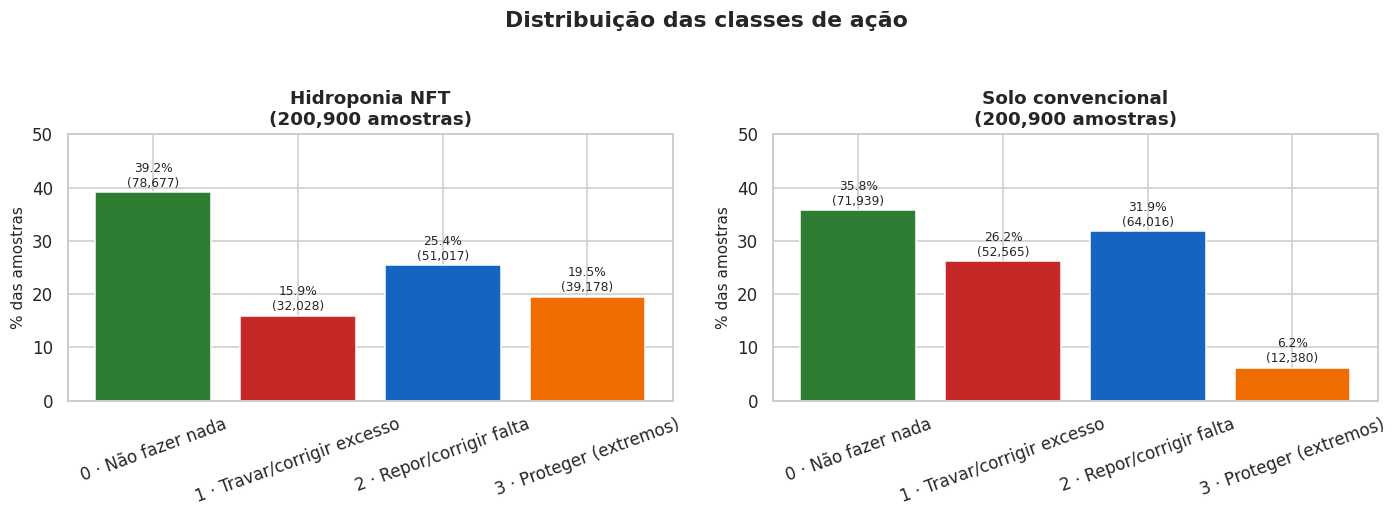

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, df, nome in zip(axes, [nft, solo], ['Hidroponia NFT', 'Solo convencional']):
    cont = df.classe_acao.value_counts().sort_index()
    pcts = 100 * cont / len(df)
    barras = ax.bar([NOMES_CLASSE[i] for i in cont.index], pcts.values,
                    color=[CORES_CLASSE[i] for i in cont.index])
    ax.set_title(f'{nome}\n({len(df):,} amostras)')
    ax.set_ylabel('% das amostras')
    ax.set_ylim(0, 50)
    ax.tick_params(axis='x', rotation=20)
    for b, p, n in zip(barras, pcts.values, cont.values):
        ax.text(b.get_x()+b.get_width()/2, p+1, f'{p:.1f}%\n({n:,})',
                ha='center', fontsize=8)

plt.suptitle('Distribuição das classes de ação', fontweight='bold', y=1.04)
plt.show()

### 3.1 Interpretação

Ambos os datasets estão **utilizáveis**: nenhuma classe é rara demais (o menor grupo tem dezenas de
milhares de amostras) e a classe 0 é majoritária, o que é **realista** — na maior parte dos dias o
cultivo está dentro do ideal e não exige intervenção.

**A diferença mais chamativa é a classe 3 (proteger): muito maior no NFT que no solo.**
Isso **não** é defeito do gerador — decorre de uma diferença agronômica real, que exploramos na Parte 12.

In [7]:
comp = pd.DataFrame({
    'NFT (%)':  (100*nft.classe_acao.value_counts(normalize=True).sort_index()).round(1),
    'Solo (%)': (100*solo.classe_acao.value_counts(normalize=True).sort_index()).round(1),
})
comp.index = [NOMES_CLASSE[i] for i in comp.index]
comp['Diferença'] = (comp['NFT (%)'] - comp['Solo (%)']).round(1)
print(comp.to_string())

                             NFT (%)  Solo (%)  Diferença
0 · Não fazer nada              39.2      35.8        3.4
1 · Travar/corrigir excesso     15.9      26.2      -10.3
2 · Repor/corrigir falta        25.4      31.9       -6.5
3 · Proteger (extremos)         19.5       6.2       13.3


## Parte 4 — Distribuições das variáveis do NFT

Aqui olhamos **uma variável por vez**: onde os valores se concentram, qual a dispersão, e se a faixa
ideal da literatura está sendo coberta. As faixas de referência (linhas tracejadas) vêm do documento
científico validado (`alface_agrolab_V2.pdf`).

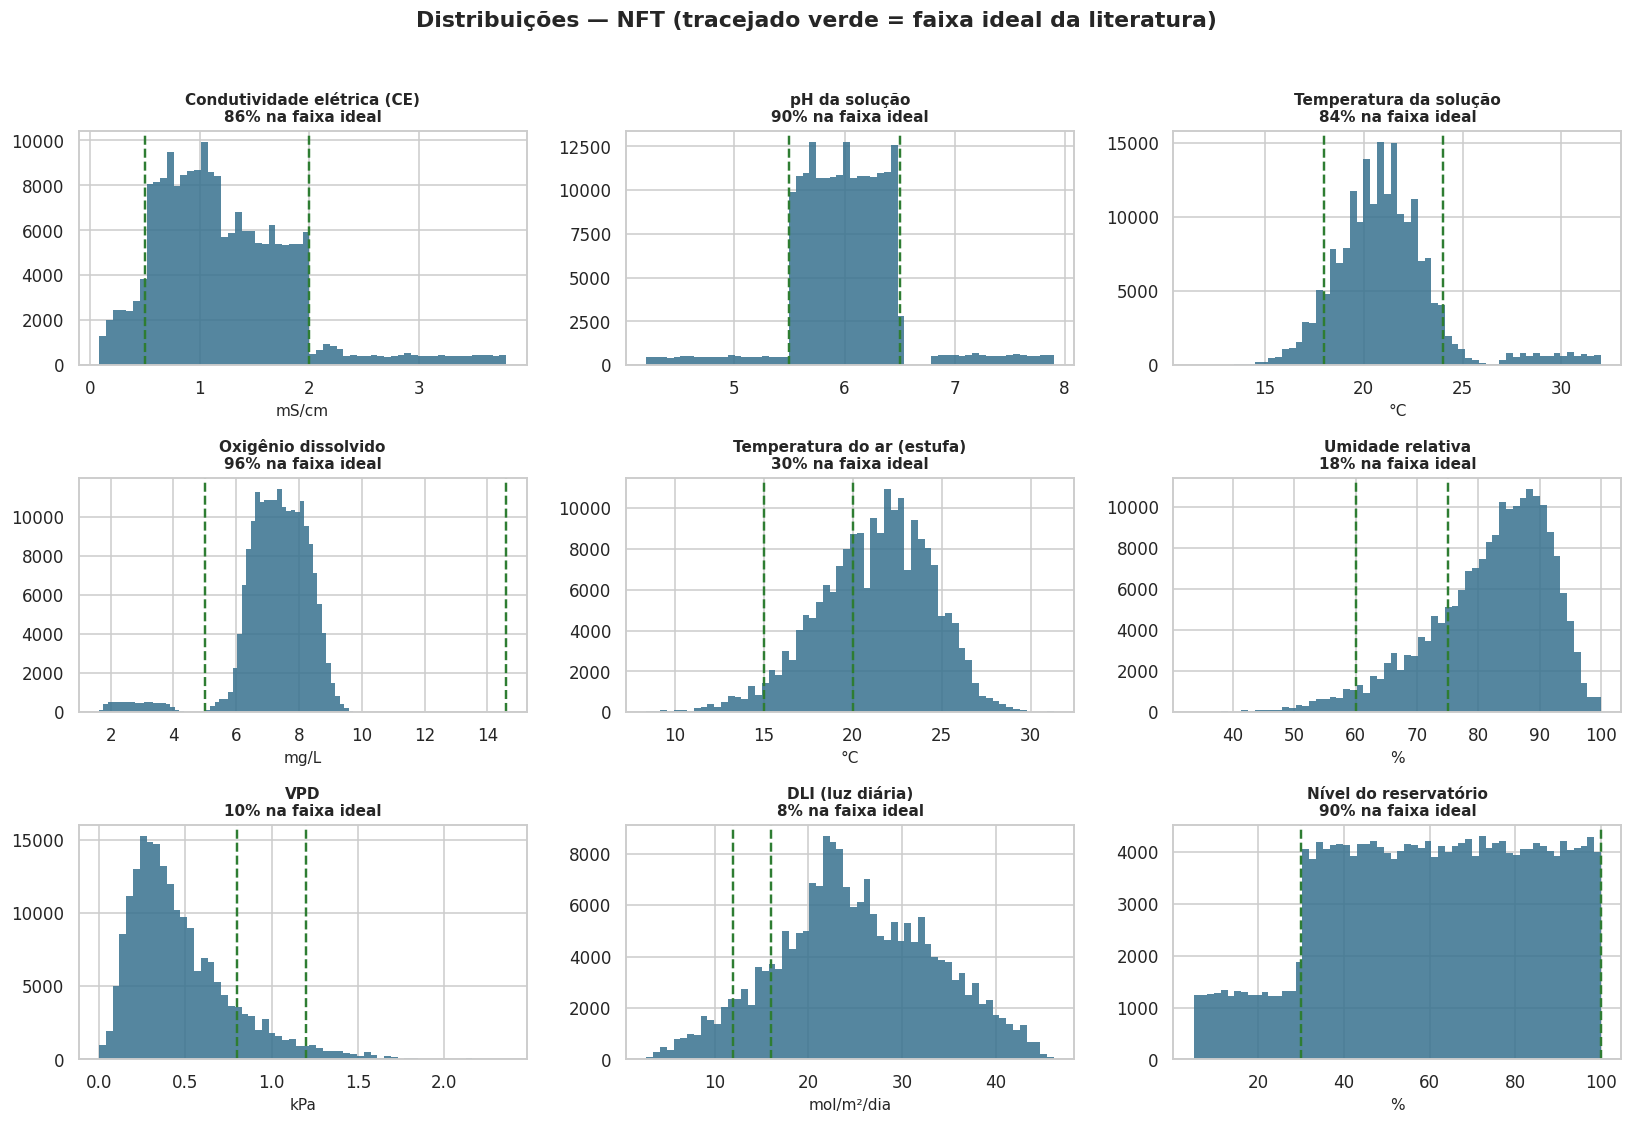

In [8]:
# (variável, título, faixa ideal, unidade)
vars_nft = [
    ('ce_ms_cm',              'Condutividade elétrica (CE)',   (0.5, 2.0),  'mS/cm'),
    ('ph',                    'pH da solução',                 (5.5, 6.5),  ''),
    ('temp_solucao_c',        'Temperatura da solução',        (18, 24),    '°C'),
    ('od_mg_l',               'Oxigênio dissolvido',           (5, 14.6),   'mg/L'),
    ('temp_ar_c',             'Temperatura do ar (estufa)',    (15, 20),    '°C'),
    ('umidade_relativa_pct',  'Umidade relativa',              (60, 75),    '%'),
    ('vpd_kpa',               'VPD',                           (0.8, 1.2),  'kPa'),
    ('dli_mol_m2_d',          'DLI (luz diária)',              (12, 16),    'mol/m²/dia'),
    ('nivel_reservatorio_pct','Nível do reservatório',         (30, 100),   '%'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, (col, titulo, (lo, hi), un) in zip(axes.ravel(), vars_nft):
    ax.hist(nft[col], bins=60, color='#37718e', alpha=.85, edgecolor='none')
    ax.axvline(lo, ls='--', lw=1.6, color='#2e7d32')
    ax.axvline(hi, ls='--', lw=1.6, color='#2e7d32')
    dentro = 100 * nft[col].between(lo, hi).mean()
    ax.set_title(f'{titulo}\n{dentro:.0f}% na faixa ideal', fontsize=10)
    ax.set_xlabel(un)
    ax.set_ylabel('')
plt.suptitle('Distribuições — NFT (tracejado verde = faixa ideal da literatura)',
             fontweight='bold', y=1.02)
plt.show()

### 4.1 Como ler estes histogramas

- **CE, pH, temperatura da solução, nível do reservatório:** o pico está dentro da faixa ideal, com
  caudas fora dela. É exatamente o desenhado: a maioria dos cenários é saudável, e uma minoria
  representa problemas — que são justamente os casos que o modelo precisa aprender a reconhecer.

- **Oxigênio dissolvido:** concentrado acima de 5 mg/L, com uma cauda baixa correspondente às falhas
  de bomba (hipóxia).

- **DLI:** fica **acima** da faixa 12–16 mol/m²/dia. Isso **não é erro**. A faixa 12–16 é o ótimo de
  *ambiente controlado com iluminação artificial* (como a bancada do projeto). Em estufa sob luz
  natural no Cinturão Verde paulista, o DLI é naturalmente maior — e é por isso que produtores usam
  **sombrite**. O dataset reflete a realidade de campo; a bancada é outro contexto.

- **VPD:** boa parte fica abaixo de 0,8 kPa. Consequência direta da alta umidade dentro da estufa —
  o que, na prática, é o cenário que favorece *tipburn* e fungos (documentado no V2 §2.7).

## Parte 5 — A CE e a fase do ciclo: o sinal mais rico do NFT

Esta é uma característica que **só existe no hidropônico** e é o que dá inteligência ao problema.

A CE ideal **não é um número fixo** — ela muda conforme a planta cresce (V2, Tab. 2):

| Fase | CE alvo (mS/cm) |
|---|---|
| Muda / berçário | 0,5 – 0,8 |
| Crescimento inicial | 0,8 – 1,2 |
| Crescimento pleno / colheita | 1,2 – 2,0 |

**Por que isso importa para a IA?** Uma CE de 0,7 mS/cm é **adequada** para uma muda, mas representa
**deficiência** para uma planta em crescimento pleno. O modelo não pode decidir olhando só a CE —
precisa cruzá-la com a fase. É um problema genuinamente não-trivial.

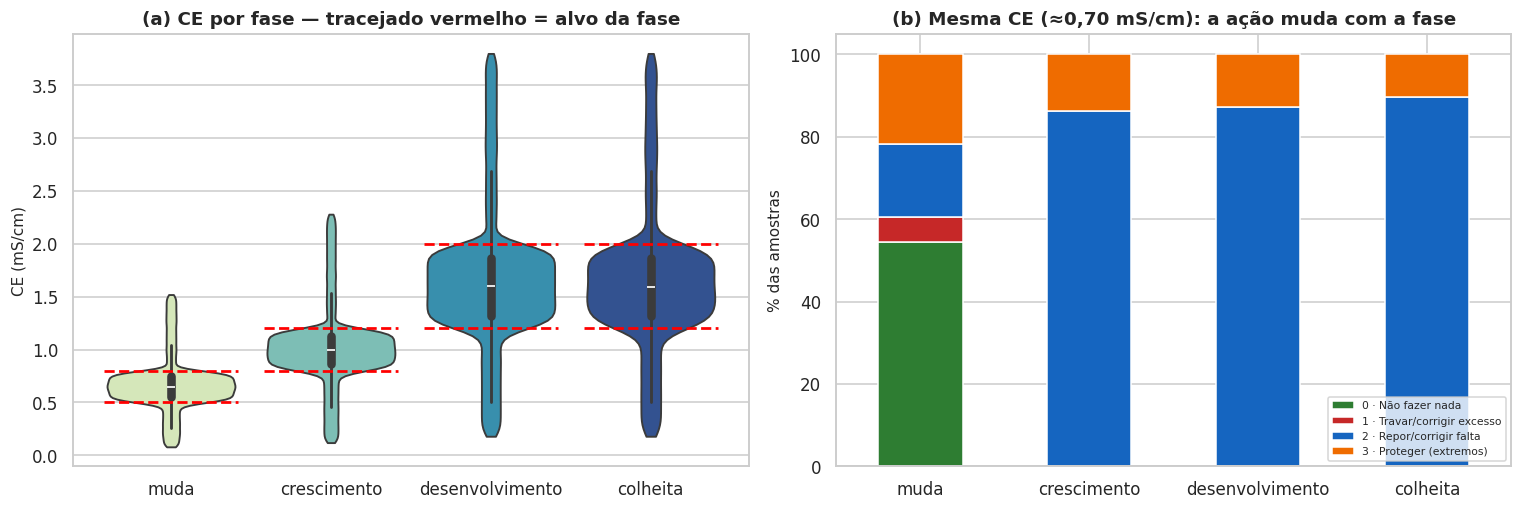

Com CE ≈ 0,70 mS/cm, a distribuição das ações por fase (%):
classe_acao         0    1     2     3
fase                                  
muda             54.5  5.9  17.8  21.8
crescimento       0.0  0.0  86.4  13.6
desenvolvimento   0.0  0.0  87.3  12.7
colheita          0.0  0.0  89.7  10.3


In [9]:
ordem_fase = ['muda','crescimento','desenvolvimento','colheita']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# (a) distribuição da CE por fase
sns.violinplot(data=nft, x='fase', y='ce_ms_cm', order=ordem_fase,
               palette='YlGnBu', ax=axes[0], cut=0)
for i, f in enumerate(ordem_fase):
    sub = nft[nft.fase == f]
    axes[0].hlines([sub.ce_alvo_min.iloc[0], sub.ce_alvo_max.iloc[0]],
                   i-.42, i+.42, color='red', ls='--', lw=1.8)
axes[0].set_title('(a) CE por fase — tracejado vermelho = alvo da fase')
axes[0].set_xlabel(''); axes[0].set_ylabel('CE (mS/cm)')

# (b) mesma CE, decisões diferentes conforme a fase
faixa = nft[nft.ce_ms_cm.between(0.65, 0.75)]
cnt = faixa.groupby(['fase','classe_acao']).size().rename('n').reset_index()
cnt['pct'] = cnt.groupby('fase')['n'].transform(lambda x: 100*x/x.sum())
piv = cnt.pivot(index='fase', columns='classe_acao', values='pct').reindex(ordem_fase).fillna(0)
piv.plot(kind='bar', stacked=True, ax=axes[1],
         color=[CORES_CLASSE[c] for c in piv.columns], legend=False)
axes[1].set_title('(b) Mesma CE (≈0,70 mS/cm): a ação muda com a fase')
axes[1].set_xlabel(''); axes[1].set_ylabel('% das amostras')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend([NOMES_CLASSE[c] for c in piv.columns], fontsize=7, loc='lower right')
plt.show()

print('Com CE ≈ 0,70 mS/cm, a distribuição das ações por fase (%):')
print(piv.round(1).to_string())

### 5.1 Interpretação

O gráfico **(a)** confirma que a CE gerada acompanha o alvo de cada fase: a mediana sobe de ~0,65 na
muda para ~1,6 no desenvolvimento.

O gráfico **(b)** é a demonstração do ponto central: **fixando a CE em ~0,70 mS/cm**, a ação correta
muda completamente conforme a fase. Na muda, esse valor está no alvo (predomina a classe 0). Nas
fases seguintes, o mesmo valor vira deficiência e passa a exigir reposição (classe 2).

> **Para o artigo:** este é um argumento concreto de por que o NFT se beneficia de decisão
> automatizada. O manejo hidropônico exige avaliar variáveis **em contexto** (fase, alvo dinâmico),
> não contra limiares fixos — precisamente o tipo de raciocínio que um modelo aprende bem e que é
> trabalhoso para um operador humano manter consistente ao longo de todo o ciclo.

## Parte 6 — As relações físicas se sustentam?

O gerador programou duas relações físicas. Aqui verificamos se elas de fato aparecem nos dados —
é um teste de que o dataset é **fisicamente coerente**, não apenas números aleatórios dentro de faixas.

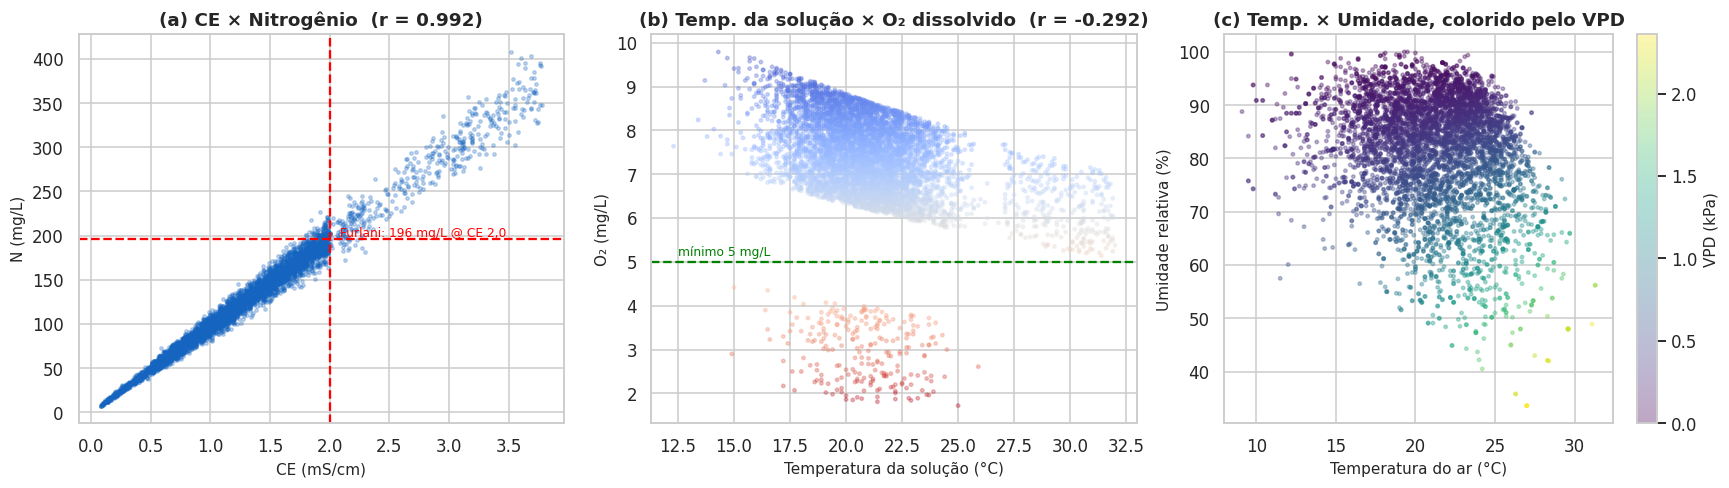

Validação (a): em CE ≈ 2,0 mS/cm, N médio = 193.8 mg/L (Furlani/IAC prevê 196 mg/L)
Validação (b): correlação temperatura × O₂ = -0.292 (negativa, como a física exige)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
amostra = nft.sample(6000, random_state=42)

# (a) CE x concentração de nutrientes
axes[0].scatter(amostra.ce_ms_cm, amostra.N, s=5, alpha=.25, color='#1565c0')
axes[0].axhline(196, ls='--', color='red', lw=1.5)
axes[0].axvline(2.0, ls='--', color='red', lw=1.5)
r_ce_n = nft.ce_ms_cm.corr(nft.N)
axes[0].set_title(f'(a) CE × Nitrogênio  (r = {r_ce_n:.3f})')
axes[0].set_xlabel('CE (mS/cm)'); axes[0].set_ylabel('N (mg/L)')
axes[0].text(2.05, 196, ' Furlani: 196 mg/L @ CE 2,0', fontsize=8, color='red', va='bottom')

# (b) temperatura da solução x oxigênio dissolvido
sc = axes[1].scatter(amostra.temp_solucao_c, amostra.od_mg_l, s=5, alpha=.3,
                     c=amostra.od_mg_l, cmap='coolwarm_r')
r_t_od = nft.temp_solucao_c.corr(nft.od_mg_l)
axes[1].axhline(5, ls='--', color='green', lw=1.5)
axes[1].set_title(f'(b) Temp. da solução × O₂ dissolvido  (r = {r_t_od:.3f})')
axes[1].set_xlabel('Temperatura da solução (°C)'); axes[1].set_ylabel('O₂ (mg/L)')
axes[1].text(12.5, 5.15, 'mínimo 5 mg/L', fontsize=8, color='green')

# (c) temperatura x umidade -> VPD
sc2 = axes[2].scatter(amostra.temp_ar_c, amostra.umidade_relativa_pct,
                      s=5, alpha=.35, c=amostra.vpd_kpa, cmap='viridis')
axes[2].set_title('(c) Temp. × Umidade, colorido pelo VPD')
axes[2].set_xlabel('Temperatura do ar (°C)'); axes[2].set_ylabel('Umidade relativa (%)')
plt.colorbar(sc2, ax=axes[2], label='VPD (kPa)')
plt.show()

plena = nft[nft.ce_ms_cm.between(1.95, 2.05)]
print(f'Validação (a): em CE ≈ 2,0 mS/cm, N médio = {plena.N.mean():.1f} mg/L '
      f'(Furlani/IAC prevê 196 mg/L)')
print(f'Validação (b): correlação temperatura × O₂ = {r_t_od:.3f} (negativa, como a física exige)')

### 6.1 Interpretação

**(a) CE × nutrientes.** A correlação é quase perfeita porque a CE *é* a medida da concentração
iônica total da solução — é assim que a hidroponia funciona na prática. A validação decisiva: em
CE ≈ 2,0 mS/cm o nitrogênio fica em torno de **196 mg/L**, exatamente o valor da solução de
referência de Furlani/IAC. O dataset reproduz a solução nutritiva brasileira consolidada.

**(b) Temperatura da solução × oxigênio.** A correlação é **negativa**, como a físico-química exige:
água mais quente dissolve menos oxigênio. A dispersão vertical existe porque a aeração (bomba)
também influencia — e é isso que gera os casos de hipóxia por falha de equipamento.

**(c) VPD.** O gradiente de cor mostra que o VPD só fica alto quando há calor **e** ar seco
simultaneamente. Isso confirma por que o VPD é métrica superior à umidade isolada (V2 §2.7).

## Parte 7 — Correlações entre variáveis

O mapa de correlações revela quais variáveis carregam informação redundante e quais são independentes.
Variáveis muito correlacionadas (|r| > 0,9) são praticamente a mesma informação.

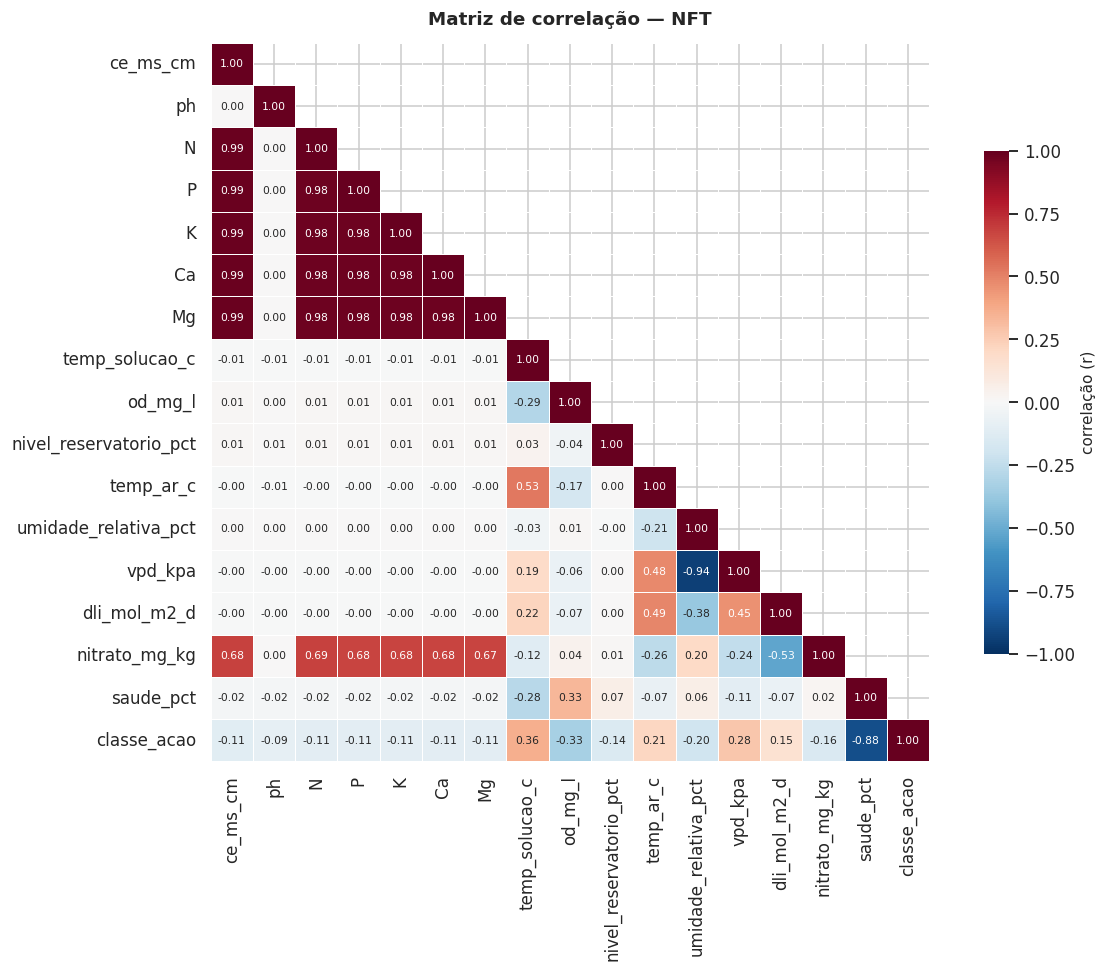

Pares mais correlacionados (|r| > 0,80):
                   A           B         r
            ce_ms_cm           P  0.991923
            ce_ms_cm           N  0.991892
            ce_ms_cm          Mg  0.991885
            ce_ms_cm           K  0.991839
            ce_ms_cm          Ca  0.991810
                   N           P  0.983874
                   N          Mg  0.983837
                   P          Mg  0.983822
                   P          Ca  0.983822
                   P           K  0.983793
                   N          Ca  0.983789
                  Ca          Mg  0.983777
                   N           K  0.983774
                   K          Mg  0.983734
                   K          Ca  0.983718
umidade_relativa_pct     vpd_kpa -0.938278
           saude_pct classe_acao -0.884874


In [11]:
cols_corr = ['ce_ms_cm','ph','N','P','K','Ca','Mg','temp_solucao_c','od_mg_l',
             'nivel_reservatorio_pct','temp_ar_c','umidade_relativa_pct',
             'vpd_kpa','dli_mol_m2_d','nitrato_mg_kg','saude_pct','classe_acao']

corr = nft[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(11.5, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            annot_kws={'size': 7}, cbar_kws={'shrink': .7, 'label': 'correlação (r)'})
plt.title('Matriz de correlação — NFT', fontweight='bold', pad=12)
plt.show()

print('Pares mais correlacionados (|r| > 0,80):')
pares = (corr.where(mask).stack().reset_index()
             .rename(columns={'level_0':'A','level_1':'B',0:'r'}))
print(pares[pares.r.abs() > .80].sort_values('r', key=abs, ascending=False)
      .to_string(index=False))

### 7.1 Interpretação — e um alerta importante

**Redundância esperada:** N, P, K, Ca e Mg são quase perfeitamente correlacionados entre si e com a
CE. Isso é fisicamente correto (todos escalam com a concentração da solução), mas significa que,
para modelagem, **a CE sozinha já carrega essa informação** — incluir os cinco nutrientes adiciona
pouco e pode até atrapalhar modelos sensíveis a colinearidade.

**VPD × umidade relativa:** forte correlação negativa, também esperada.

> ⚠️ **Alerta sobre `saude_pct`.** Esta variável aparece correlacionada com `classe_acao`, mas isso é
> **circular**: nós a construímos *a partir* da classe de ação (`info.md` §8.3). Ela **não pode** ser
> usada como preditora nem interpretada como descoberta. Vamos excluí-la da modelagem na Parte 11.

## Parte 8 — Sazonalidade: quando o cultivo exige mais atenção

As variáveis ambientais vêm de 11 anos de clima real. Isso permite ver **em que época do ano** as
intervenções se concentram — informação de valor prático direto para o produtor.

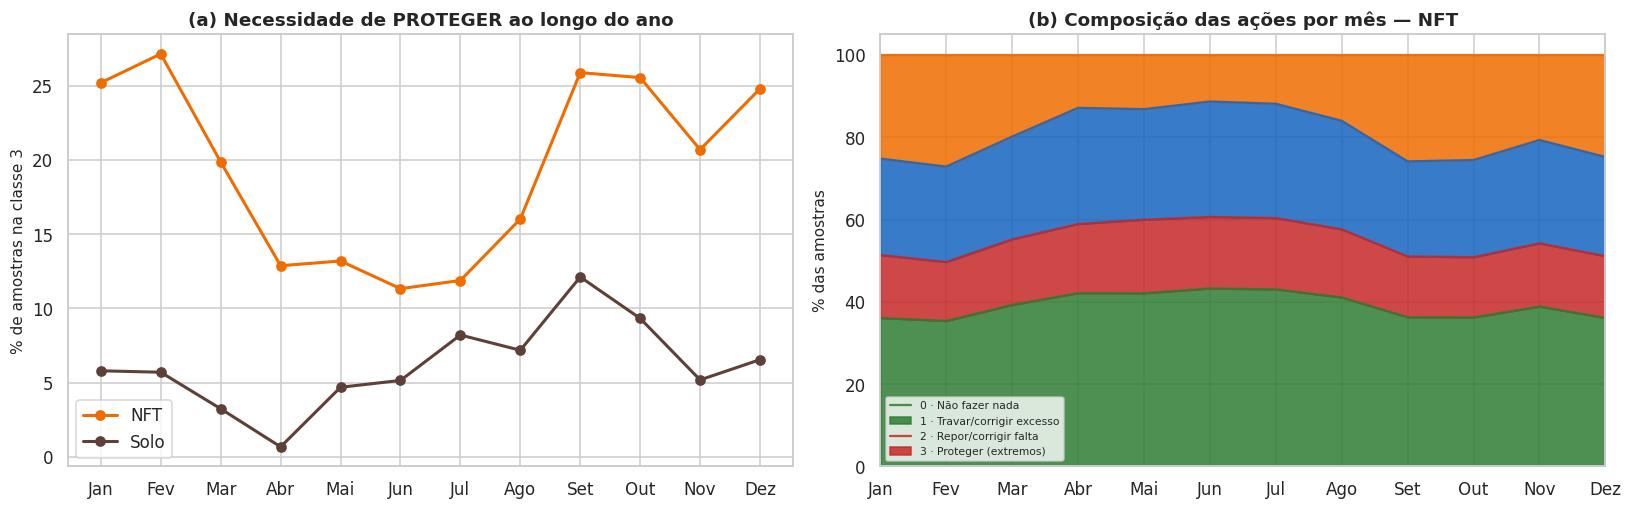

Motivos de PROTEGER por mês (NFT):
motivo  proteger: calor agudo (T_max>32C)  proteger: calor sustentado (pendoamento)  proteger: frio/geada (T_min<7C)  proteger: hipoxia radicular (OD<4 mg/L)  proteger: solucao quente (>27C, queda de O2)
Jan                                   761                                      2300                                0                                      531                                           705
Fev                                   787                                      2339                                0                                      491                                           604
Mar                                   664                                      1374                                0                                      599                                           750
Abr                                   314                                       399                                0                                 

In [12]:
nft['mes'] = nft.timestamp.dt.month
solo['mes'] = solo.timestamp.dt.month
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# (a) classe 3 por mês, nos dois sistemas
for df, nome, cor in [(nft,'NFT','#ef6c00'), (solo,'Solo','#5d4037')]:
    serie = df.groupby('mes').classe_acao.apply(lambda x: 100*(x==3).mean())
    axes[0].plot(range(1,13), serie.values, marker='o', label=nome, color=cor, lw=2)
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(meses)
axes[0].set_title('(a) Necessidade de PROTEGER ao longo do ano')
axes[0].set_ylabel('% de amostras na classe 3'); axes[0].legend()

# (b) composição das classes por mês (NFT)
_cm = nft.groupby(['mes','classe_acao']).size().rename('n').reset_index()
_cm['pct'] = _cm.groupby('mes')['n'].transform(lambda x: 100*x/x.sum())
comp_mes = _cm.pivot(index='mes', columns='classe_acao', values='pct')
comp_mes.plot(kind='area', stacked=True, ax=axes[1],
              color=[CORES_CLASSE[c] for c in comp_mes.columns], alpha=.85)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses)
axes[1].set_title('(b) Composição das ações por mês — NFT')
axes[1].set_xlabel(''); axes[1].set_ylabel('% das amostras'); axes[1].set_xlim(1,12)
axes[1].legend([NOMES_CLASSE[c] for c in comp_mes.columns], fontsize=7, loc='lower left')
plt.show()

motivos_mes = (nft[nft.classe_acao==3].groupby(['mes','motivo']).size()
                  .unstack(fill_value=0))
motivos_mes.index = meses
print('Motivos de PROTEGER por mês (NFT):')
print(motivos_mes.to_string())

### 8.1 Interpretação

A necessidade de proteger tem **forma sazonal clara**, com pico no verão (dezembro a março) — período
de calor no Cinturão Verde paulista, quando o risco de pendoamento e estresse térmico aumenta.

A tabela de motivos mostra a **inversão sazonal**: no inverno predomina a proteção contra frio; no
verão, contra calor (do ar e da solução). Um sistema de decisão precisa lidar com os dois regimes.

> **Para o artigo:** este resultado é derivado de clima real e sustenta a afirmação de que o manejo
> da alface no Cinturão Verde tem **janelas críticas sazonais** — e que a automação da decisão é mais
> valiosa justamente nesses períodos.

## Parte 9 — Cultivar: a genética desloca os limiares

Um mesmo dia quente não afeta todas as cultivares igualmente. Cultivares tolerantes ao calor
('Vera', 'Verônica', 'Vanda') pendoam a temperaturas mais altas que as padrão (V2 §2.3).

Este é um fator que o modelo precisa considerar: **a decisão depende da planta, não só do ambiente**.

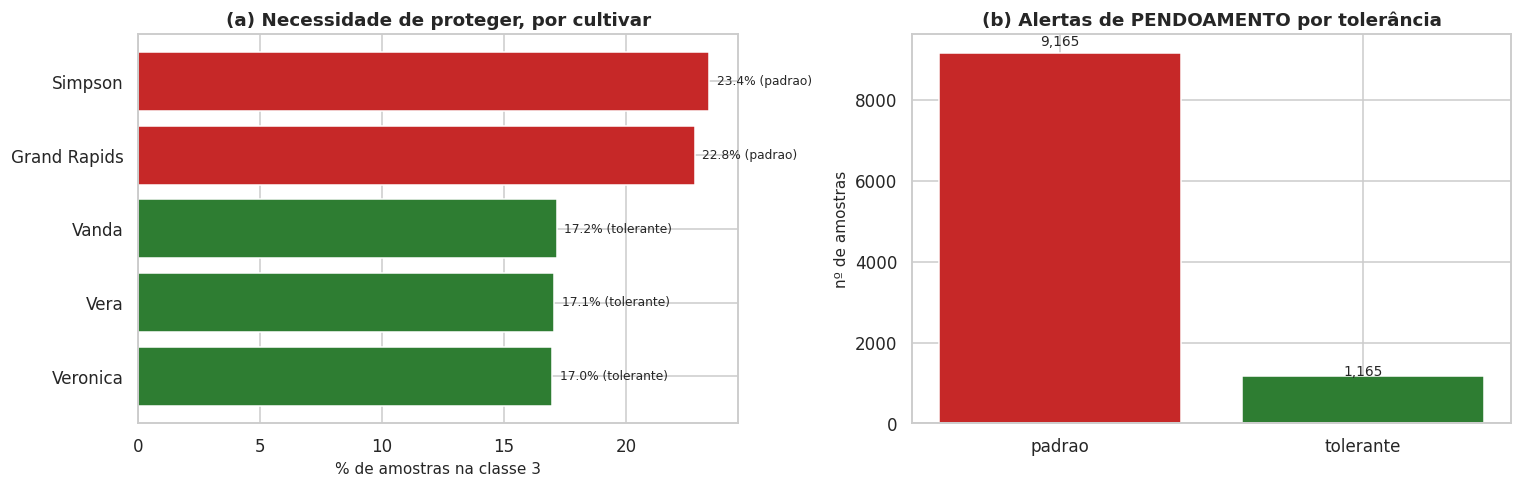

Cultivares padrão acionam alerta de pendoamento 7.9x mais que as tolerantes.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# (a) % classe 3 por cultivar
por_cult = (nft.groupby(['cultivar','tolerancia_calor']).classe_acao
              .apply(lambda x: 100*(x==3).mean()).reset_index(name='pct')
              .sort_values('pct'))
cores = ['#2e7d32' if t=='tolerante' else '#c62828' for t in por_cult.tolerancia_calor]
axes[0].barh(por_cult.cultivar, por_cult.pct, color=cores)
axes[0].set_title('(a) Necessidade de proteger, por cultivar')
axes[0].set_xlabel('% de amostras na classe 3')
for i,(p,t) in enumerate(zip(por_cult.pct, por_cult.tolerancia_calor)):
    axes[0].text(p+.3, i, f'{p:.1f}% ({t})', va='center', fontsize=8)

# (b) pendoamento especificamente
pend = nft[nft.motivo.str.contains('pendoamento')]
cont = pend.tolerancia_calor.value_counts()
axes[1].bar(cont.index, cont.values,
            color=['#c62828' if i=='padrao' else '#2e7d32' for i in cont.index])
axes[1].set_title('(b) Alertas de PENDOAMENTO por tolerância')
axes[1].set_ylabel('nº de amostras')
for i,(k,v) in enumerate(cont.items()):
    axes[1].text(i, v*1.02, f'{v:,}', ha='center', fontsize=9)
plt.show()

razao = cont.get('padrao',0) / max(cont.get('tolerante',1), 1)
print(f'Cultivares padrão acionam alerta de pendoamento {razao:.1f}x mais que as tolerantes.')

### 9.1 Interpretação

O efeito é grande: cultivares padrão disparam alertas de pendoamento **muitas vezes mais** que as
tolerantes, sob exatamente o mesmo clima.

> **Para o artigo:** isso mostra que a recomendação de manejo **não pode ser genérica**. Um sistema de
> apoio à decisão que ignore a cultivar erra sistematicamente — ou protege demais (custo
> desnecessário) ou protege de menos (perda por pendoamento). É um argumento a favor de modelos que
> incorporem a genética como variável.

## Parte 10 — As classes são separáveis?

Antes de treinar qualquer modelo, vale perguntar: **as quatro ações formam grupos distinguíveis no
espaço das variáveis?** Se as classes estiverem completamente embaralhadas, nenhum modelo aprenderá.

Usamos PCA (Análise de Componentes Principais) para projetar as variáveis em duas dimensões e
inspecionar visualmente.

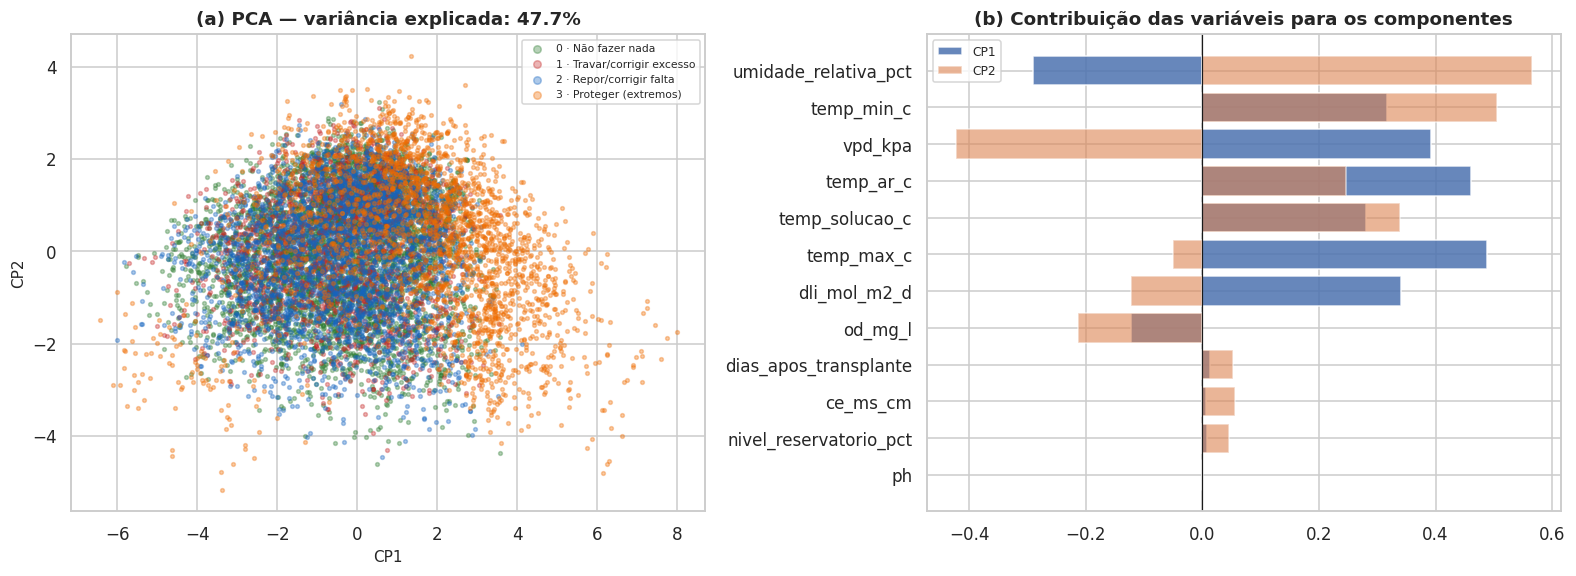

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feats_pca = ['ce_ms_cm','ph','temp_solucao_c','od_mg_l','nivel_reservatorio_pct',
             'temp_ar_c','temp_max_c','temp_min_c','umidade_relativa_pct',
             'vpd_kpa','dli_mol_m2_d','dias_apos_transplante']

amo = nft.sample(12000, random_state=42)
X = StandardScaler().fit_transform(amo[feats_pca])
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

for cl in [0,1,2,3]:
    m = (amo.classe_acao == cl).values
    axes[0].scatter(proj[m,0], proj[m,1], s=6, alpha=.35,
                    color=CORES_CLASSE[cl], label=NOMES_CLASSE[cl])
axes[0].set_title(f'(a) PCA — variância explicada: '
                  f'{100*pca.explained_variance_ratio_.sum():.1f}%')
axes[0].set_xlabel('CP1'); axes[0].set_ylabel('CP2')
axes[0].legend(fontsize=7, markerscale=2)

carga = pd.DataFrame(pca.components_.T, index=feats_pca, columns=['CP1','CP2'])
carga['peso'] = carga.abs().sum(axis=1)
carga = carga.sort_values('peso', ascending=True)
axes[1].barh(carga.index, carga.CP1, label='CP1', alpha=.85)
axes[1].barh(carga.index, carga.CP2, label='CP2', alpha=.6)
axes[1].set_title('(b) Contribuição das variáveis para os componentes')
axes[1].legend(fontsize=8); axes[1].axvline(0, color='k', lw=.8)
plt.show()

### 10.1 Interpretação

As classes formam **regiões parcialmente distinguíveis**, com sobreposição. Isso é o cenário
desejável: se estivessem perfeitamente separadas em duas dimensões, o problema seria trivial demais;
se estivessem totalmente misturadas, seria insolúvel.

A sobreposição existe porque a decisão depende de **combinações e contexto** (por exemplo, CE em
relação à fase), o que duas componentes lineares não capturam. É a justificativa para usar modelos
não-lineares como Random Forest.

## Parte 11 — O dataset é aprendível? (baseline)

Treinamos um **Random Forest** como referência. O objetivo aqui **não é** provar nada sobre agronomia —
é responder a uma pergunta técnica: *o dataset contém sinal suficiente e consistente para que um
modelo recupere as regras de decisão?*

**Cuidados metodológicos aplicados:**
- Excluímos `saude_pct` e `nitrato_mg_kg` (derivados do rótulo ou proxies — usá-los seria vazamento).
- Excluímos `motivo` (é a resposta escrita em texto).
- Excluímos `ce_alvo_min` / `ce_alvo_max` (entregariam a regra da fase de bandeja).
- Separação treino/teste **estratificada**.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)

feats = ['ce_ms_cm','ph','N','temp_solucao_c','od_mg_l','nivel_reservatorio_pct',
         'temp_ar_c','temp_max_c','temp_min_c','umidade_relativa_pct',
         'vpd_kpa','dli_mol_m2_d','dias_apos_transplante']
cat = pd.get_dummies(nft[['fase','tolerancia_calor']], drop_first=True)
X = pd.concat([nft[feats], cat], axis=1)
y = nft.classe_acao

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=120, max_depth=18, min_samples_leaf=5,
                            n_jobs=-1, random_state=42, class_weight='balanced')
rf.fit(X_tr, y_tr)
pred = rf.predict(X_te)

print(f'Acurácia : {accuracy_score(y_te, pred):.3f}')
print(f'F1 macro : {f1_score(y_te, pred, average="macro"):.3f}\n')
print(classification_report(y_te, pred,
      target_names=[NOMES_CLASSE[i] for i in sorted(y.unique())]))

Acurácia : 0.985
F1 macro : 0.983

                             precision    recall  f1-score   support

         0 · Não fazer nada       0.99      0.99      0.99     19669
1 · Travar/corrigir excesso       0.98      1.00      0.99      8007
   2 · Repor/corrigir falta       0.99      1.00      0.99     12754
    3 · Proteger (extremos)       0.98      0.94      0.96      9795

                   accuracy                           0.98     50225
                  macro avg       0.98      0.98      0.98     50225
               weighted avg       0.98      0.98      0.98     50225



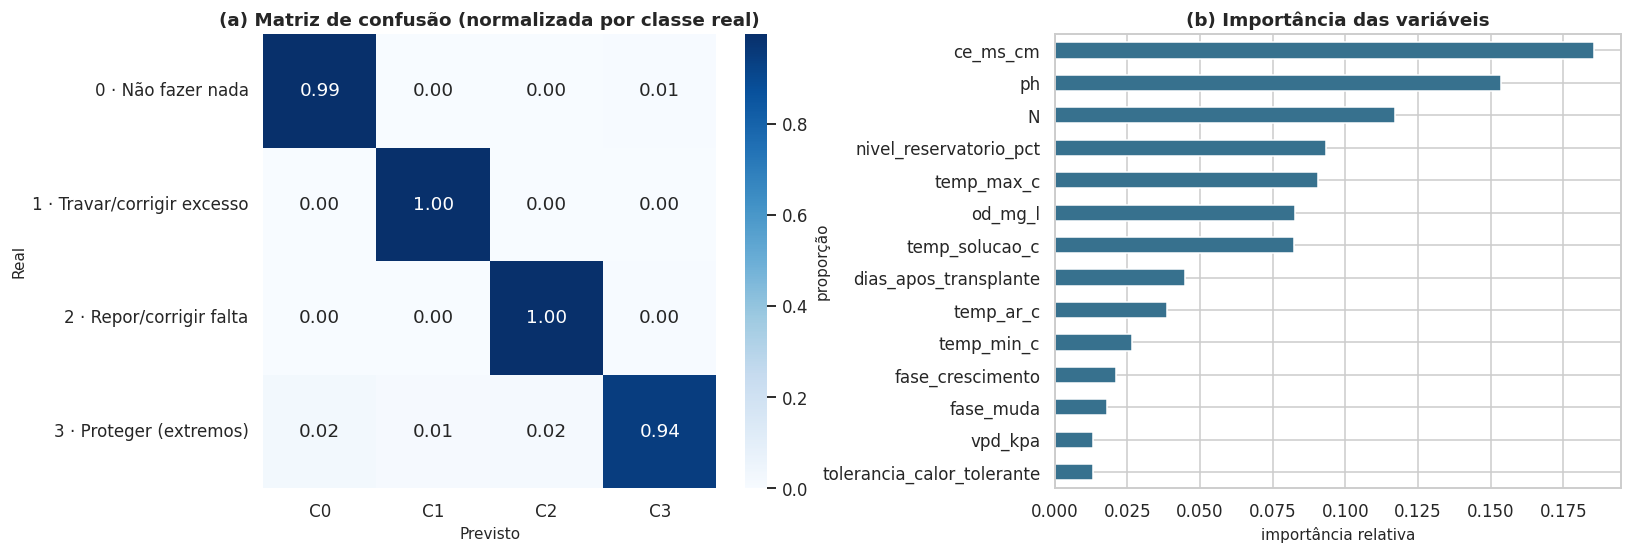

Top 8 variáveis:
ce_ms_cm                  18.6
ph                        15.4
N                         11.7
nivel_reservatorio_pct     9.3
temp_max_c                 9.1
od_mg_l                    8.3
temp_solucao_c             8.2
dias_apos_transplante      4.5


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# matriz de confusão normalizada
cm = confusion_matrix(y_te, pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=[f'C{i}' for i in range(4)],
            yticklabels=[NOMES_CLASSE[i] for i in range(4)],
            cbar_kws={'label':'proporção'})
axes[0].set_title('(a) Matriz de confusão (normalizada por classe real)')
axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')

# importância das variáveis
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.tail(14).plot(kind='barh', ax=axes[1], color='#37718e')
axes[1].set_title('(b) Importância das variáveis')
axes[1].set_xlabel('importância relativa')
plt.show()

print('Top 8 variáveis:')
print((100*imp.sort_values(ascending=False).head(8)).round(1).to_string())

### 11.1 Interpretação — e o que este resultado **não** significa

O modelo recupera as regras com desempenho alto. Isso confirma que **o dataset é consistente e
aprendível**: não há contradições internas que impeçam o aprendizado.

> ⚠️ **Este número não deve ser apresentado como "a IA acertou X% no manejo da alface".**
> As regras de rotulagem são determinísticas e foram definidas por nós; o modelo está,
> essencialmente, **redescobrindo regras conhecidas**. Um desempenho alto aqui é *esperado* e valida
> a consistência do dataset — não a capacidade preditiva no mundo real.
>
> A avaliação honesta de desempenho exigirá **dados reais** da bancada NFT (protocolo TSTR descrito
> em `info.md` §9). Este baseline é o ponto de partida, não a conclusão.

**O que é legítimo afirmar:** as variáveis mais importantes indicam onde está o sinal — e elas
correspondem às variáveis que a literatura aponta como críticas, o que é um sinal de coerência
entre o dataset e o conhecimento agronômico consolidado.

## Parte 12 — NFT × Solo: o argumento defensável

Chegamos ao ponto que interessa ao artigo. Como alertado no início, **não podemos** usar estes dados
sintéticos para afirmar que o NFT produz mais. Mas podemos sustentar, com dados, um argumento
diferente e mais preciso: **o NFT é um sistema mais instrumentável, mais controlável e mais exigente
em vigilância — e é exatamente por isso que se beneficia mais de decisão automatizada.**

                                    Hidroponia NFT Solo convencional
Variáveis controláveis (alavancas)              10                 5
Tipos distintos de intervenção                  11                10
Dias que exigem alguma ação                  60.8%             64.2%
Dias que exigem proteção (classe 3)          19.5%              6.2%


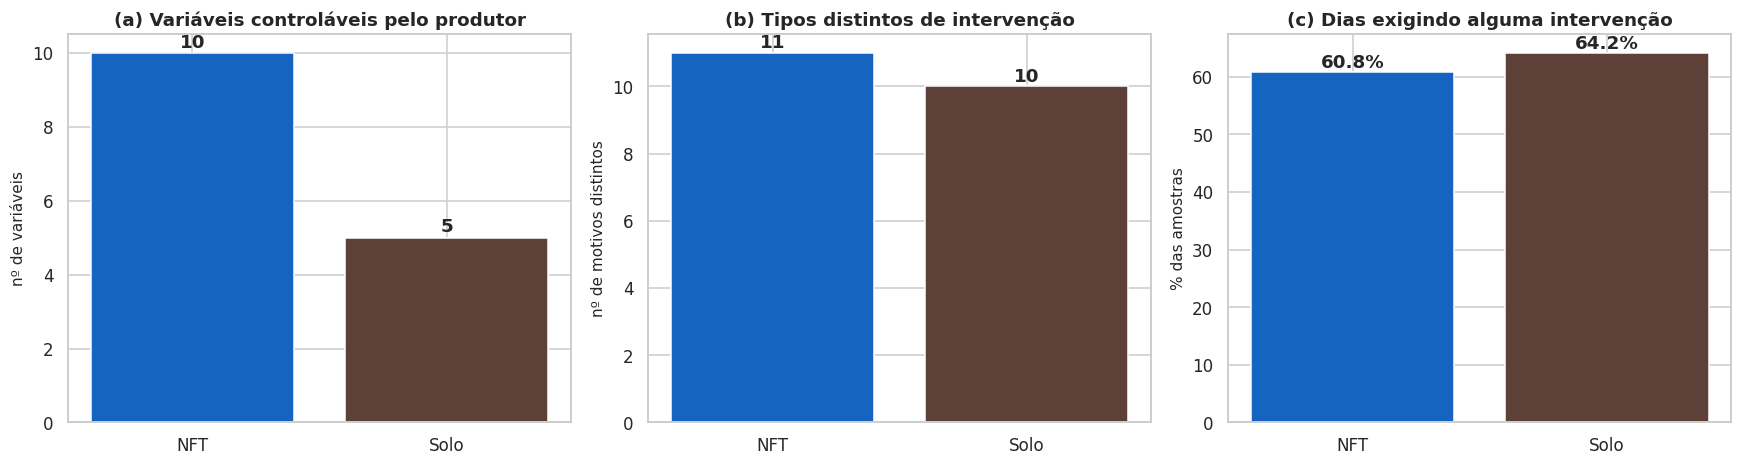

In [17]:
# --- 1) Variáveis acionáveis: quantas alavancas de controle cada sistema oferece?
acionaveis_nft = ['ce_ms_cm','ph','N','P','K','Ca','Mg','temp_solucao_c',
                  'od_mg_l','nivel_reservatorio_pct']
acionaveis_solo = ['N','P','K','ph','umidade_solo_pct']

# --- 2) Frequência e diversidade de intervenção
div_nft  = nft.motivo.nunique()
div_solo = solo.motivo.nunique()
int_nft  = 100*(nft.classe_acao != 0).mean()
int_solo = 100*(solo.classe_acao != 0).mean()

resumo = pd.DataFrame({
    'Hidroponia NFT': [len(acionaveis_nft), div_nft, f'{int_nft:.1f}%',
                       f'{100*(nft.classe_acao==3).mean():.1f}%'],
    'Solo convencional': [len(acionaveis_solo), div_solo, f'{int_solo:.1f}%',
                          f'{100*(solo.classe_acao==3).mean():.1f}%'],
}, index=['Variáveis controláveis (alavancas)',
          'Tipos distintos de intervenção',
          'Dias que exigem alguma ação',
          'Dias que exigem proteção (classe 3)'])
print(resumo.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].bar(['NFT','Solo'], [len(acionaveis_nft), len(acionaveis_solo)],
            color=['#1565c0','#5d4037'])
axes[0].set_title('(a) Variáveis controláveis pelo produtor')
axes[0].set_ylabel('nº de variáveis')
for i,v in enumerate([len(acionaveis_nft), len(acionaveis_solo)]):
    axes[0].text(i, v+.15, str(v), ha='center', fontweight='bold')

axes[1].bar(['NFT','Solo'], [div_nft, div_solo], color=['#1565c0','#5d4037'])
axes[1].set_title('(b) Tipos distintos de intervenção')
axes[1].set_ylabel('nº de motivos distintos')
for i,v in enumerate([div_nft, div_solo]):
    axes[1].text(i, v+.15, str(v), ha='center', fontweight='bold')

axes[2].bar(['NFT','Solo'], [int_nft, int_solo], color=['#1565c0','#5d4037'])
axes[2].set_title('(c) Dias exigindo alguma intervenção')
axes[2].set_ylabel('% das amostras')
for i,v in enumerate([int_nft, int_solo]):
    axes[2].text(i, v+.8, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

### 12.1 Por que a classe 3 é maior no NFT? O tamponamento

Esta é a diferença mais visível entre os sistemas, e ela tem explicação agronômica sólida —
**não é artefato do gerador**:

O **solo** funciona como um amortecedor. Ele armazena água e nutrientes, e sua inércia térmica e
hídrica absorve oscilações. Se a irrigação falha num dia quente, a planta ainda dispõe da água retida
no perfil.

O **NFT não tem esse amortecedor**. A planta vive num filme de solução em circulação contínua. Se a
bomba para, as raízes ficam sem oxigênio em horas. Se a solução aquece acima de 27 °C, o oxigênio
dissolvido despenca. Não há reserva a que recorrer.

O documento científico registra isso explicitamente: o sistema hidropônico tem **menor capacidade de
tamponamento** que o solo.

> **Consequência para o artigo — e é aqui que o argumento fecha:**
> O NFT entrega ganhos expressivos de produtividade, eficiência hídrica e uso de terra (evidência da
> literatura), mas **ao custo de uma janela de tolerância a erros muito menor**. Um sistema que exige
> vigilância constante e resposta rápida é precisamente o caso de uso onde **monitoramento
> automatizado e decisão assistida por IA agregam mais valor** — enquanto no solo o produtor dispõe
> de mais margem para corrigir um descuido.
>
> Esta é uma justificativa **honesta** para focar o projeto no NFT: não porque nossos dados provem
> que ele é superior, mas porque ele é o sistema em que a contribuição da IA é mais crítica.

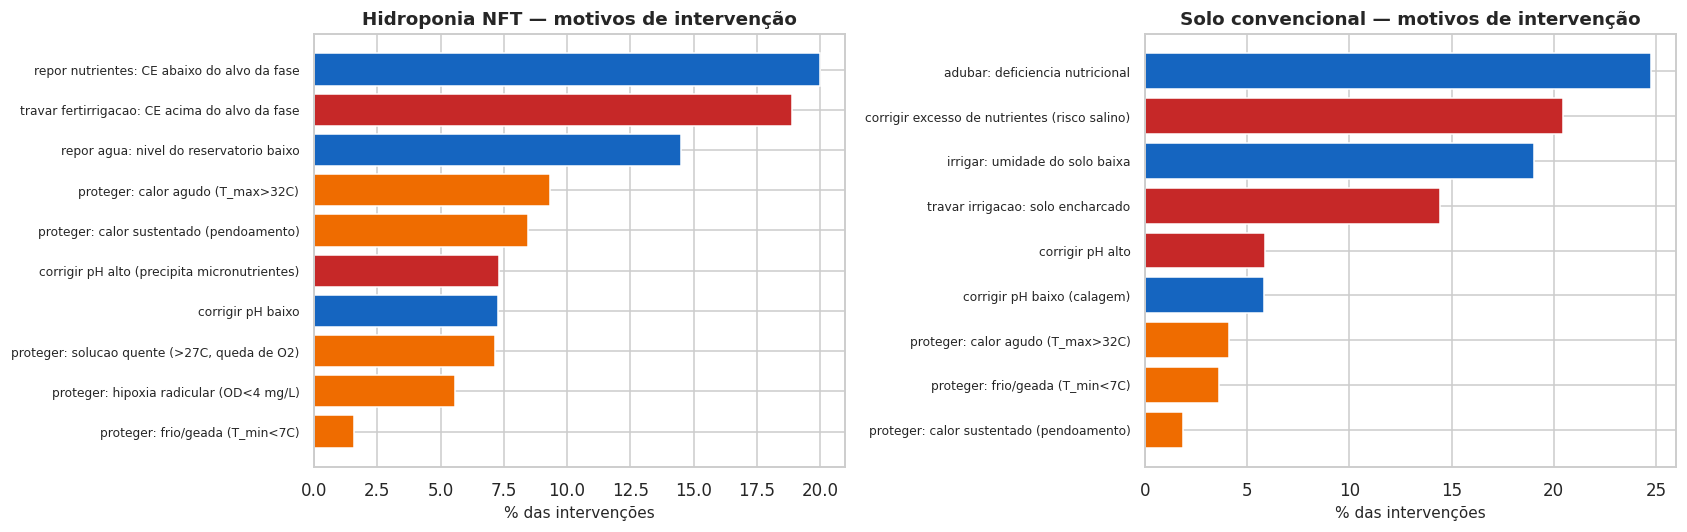

In [18]:
# Comparação dos motivos de intervenção entre os sistemas
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5))
for ax, df, nome in zip(axes, [nft, solo], ['Hidroponia NFT','Solo convencional']):
    mm = (df[df.classe_acao!=0].motivo.value_counts(normalize=True)*100).sort_values()
    cores_m = [CORES_CLASSE[df[df.motivo==m].classe_acao.iloc[0]] for m in mm.index]
    ax.barh(range(len(mm)), mm.values, color=cores_m)
    ax.set_yticks(range(len(mm)))
    ax.set_yticklabels([m[:52] for m in mm.index], fontsize=8)
    ax.set_title(f'{nome} — motivos de intervenção')
    ax.set_xlabel('% das intervenções')
plt.show()

### 12.2 Leitura dos motivos

No **solo**, as intervenções concentram-se em água e nutrição — variáveis de resposta lenta, com
margem para correção.

No **NFT**, além dessas, surgem categorias **inexistentes no solo**: hipóxia radicular, solução
superaquecida, reservatório vazio. São falhas de **sistema técnico**, de instalação rápida e efeito
severo — o tipo de ocorrência que um sensor detecta em minutos e um humano pode levar horas a notar.

## Parte 13 — Síntese para o artigo

### O que esta EDA demonstrou

| # | Achado | Onde |
|---|--------|------|
| 1 | Datasets íntegros: sem nulos, sem duplicatas, sem violações físicas | Parte 2 |
| 2 | Rotulagem coerente: cada motivo mapeia sempre na mesma classe | Parte 2 |
| 3 | Classes balanceadas o suficiente para treino, com classe 0 majoritária (realista) | Parte 3 |
| 4 | Variáveis cobrem as faixas da literatura, com caudas representando os problemas | Parte 4 |
| 5 | **A CE alvo muda com a fase** — decisão exige contexto, não limiar fixo | Parte 5 |
| 6 | Relações físicas se sustentam: N ≈ 196 mg/L em CE 2,0 (Furlani); T × O₂ negativa | Parte 6 |
| 7 | Nutrientes redundantes com a CE — usar a CE como representante | Parte 7 |
| 8 | Sazonalidade clara: proteção contra calor no verão, contra frio no inverno | Parte 8 |
| 9 | Cultivar desloca fortemente os limiares — recomendação não pode ser genérica | Parte 9 |
| 10 | Classes parcialmente separáveis: problema não-trivial, adequado a modelos não-lineares | Parte 10 |
| 11 | Dataset aprendível: o modelo recupera as regras (valida consistência, não agronomia) | Parte 11 |
| 12 | NFT tem o dobro de variáveis controláveis e mais modos de falha que o solo | Parte 12 |

### Como justificar o NFT no artigo (redação sugerida)

> A opção pelo sistema hidropônico NFT fundamenta-se em duas ordens de razão. **Primeira**, a
> evidência consolidada na literatura de ganhos expressivos em produtividade por área, eficiência no
> uso da água e redução do ciclo produtivo, ainda que com maior custo energético e de capital.
> **Segunda**, e determinante para os objetivos deste trabalho, a menor capacidade de tamponamento do
> sistema: enquanto o solo armazena água e nutrientes e absorve oscilações de manejo, o NFT opera sem
> reserva, de modo que falhas técnicas — interrupção do bombeamento, aquecimento da solução,
> depleção do reservatório — produzem efeitos severos em intervalos curtos. A análise exploratória
> quantificou essa diferença: o sistema hidropônico apresentou o dobro de variáveis controláveis e
> categorias de intervenção inexistentes no cultivo em solo. Trata-se, portanto, do contexto em que o
> monitoramento contínuo e a decisão assistida por inteligência artificial oferecem maior
> contribuição potencial.

### Limitações a declarar

1. Os dados de manejo são **sintéticos**, gerados por regras derivadas da literatura — a EDA
   caracteriza o dataset, não constitui evidência agronômica nova.
2. O desempenho do baseline reflete a **consistência interna** das regras, não capacidade preditiva
   em condições reais.
3. Colunas assinaladas como *proxy* (`nitrato_mg_kg`, `saude_pct`, `temp_solo_c`, `N` no solo)
   são estimativas — ver `info.md` §8.
4. A validação definitiva exige dados reais da bancada NFT, pelo protocolo TSTR (`info.md` §9).

### Próximos passos

- Instrumentar a bancada NFT e coletar dados reais.
- Aplicar o protocolo **TSTR** (treinar no sintético, testar no real).
- Comparar o desempenho do modelo com decisões de operadores humanos — o objetivo central do projeto.